# FactLens — Step 12: Cross-Task Analysis

**Goal:** Compare what linguistic signals drive *fake news detection* (Dataset 1) vs *political bias detection* (Dataset 2).

Key questions:
1. Do fake-news words overlap with political-bias words?
2. Are fake articles more "Left" or "Right" in their language?
3. Do the two tasks share linguistic fingerprints, or are they orthogonal?
4. What does this tell us about the nature of misinformation vs political framing?

## 0. Setup — paths and imports

In [9]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR1  = "/content/drive/MyDrive/FactLens_Group9/data"
DATA_DIR2  = "/content/drive/MyDrive/FactLens_Group9/data2"
ARTIFACTS2 = "/content/drive/MyDrive/FactLens_Group9/data2/artifacts"

D1_LR       = f"{DATA_DIR1}/logistic_regression_model.pkl"
D1_TFIDF    = f"{DATA_DIR1}/tfidf_vectorizer.pkl"
D1_FEATURES = f"{DATA_DIR1}/df_with_features.csv"
D2_LR       = f"{ARTIFACTS2}/left_right_logreg.pkl"
D2_TFIDF    = f"{ARTIFACTS2}/tfidf_vectorizer.pkl"
D2_CSV      = f"{DATA_DIR2}/news_bias.csv"

# ── Verify all required files exist ────────────────────────────────────────
import os
required = {
    "D1 LR model":     D1_LR,
    "D1 TF-IDF":       D1_TFIDF,
    "D1 features CSV": D1_FEATURES,
    "D2 LR model":     D2_LR,
    "D2 TF-IDF":       D2_TFIDF,
    "D2 raw CSV":      D2_CSV,
}
all_ok = True
for label, path in required.items():
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING'}  {label:20s}  {path}")
    if not exists:
        all_ok = False
print()
print("All files found!" if all_ok else "FIX MISSING FILES BEFORE CONTINUING.")

  OK  D1 LR model           /content/drive/MyDrive/FactLens_Group9/data/logistic_regression_model.pkl
  OK  D1 TF-IDF             /content/drive/MyDrive/FactLens_Group9/data/tfidf_vectorizer.pkl
  OK  D1 features CSV       /content/drive/MyDrive/FactLens_Group9/data/df_with_features.csv
  OK  D2 LR model           /content/drive/MyDrive/FactLens_Group9/data2/artifacts/left_right_logreg.pkl
  OK  D2 TF-IDF             /content/drive/MyDrive/FactLens_Group9/data2/artifacts/tfidf_vectorizer.pkl
  OK  D2 raw CSV            /content/drive/MyDrive/FactLens_Group9/data2/news_bias.csv

All files found!


In [11]:
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
print("Imports OK.")

Imports OK.


## 1. Load models from both datasets

In [12]:
with open(D1_LR,    "rb") as f: lr_d1  = pickle.load(f)
with open(D1_TFIDF, "rb") as f: vec_d1 = pickle.load(f)
with open(D2_LR,    "rb") as f: lr_d2  = pickle.load(f)
with open(D2_TFIDF, "rb") as f: vec_d2 = pickle.load(f)

print("Loaded:")
print(f"  D1 LR — {len(lr_d1.coef_[0]):,} features  (negative=Real, positive=Fake)")
print(f"  D2 LR — {len(lr_d2.coef_[0]):,} features  (negative=Left, positive=Right)")

Loaded:
  D1 LR — 50,000 features  (negative=Real, positive=Fake)
  D2 LR — 40,005 features  (negative=Left, positive=Right)


In [13]:
# D1: TF-IDF only (50,000 features)
d1_names = vec_d1.get_feature_names_out()
df_d1 = pd.DataFrame({"word": d1_names, "coef_d1": lr_d1.coef_[0]}).set_index("word")

# D2: TF-IDF (40,000) + 5 linguistic features
d2_tfidf_names = list(vec_d2.get_feature_names_out())
d2_extra_names = ["sentiment", "subjectivity", "readability", "exclamation_count", "question_count"]
df_d2 = pd.DataFrame(
    {"word": d2_tfidf_names + d2_extra_names, "coef_d2": lr_d2.coef_[0]}
).set_index("word")

print(f"D1 vocabulary: {len(df_d1):,} terms")
print(f"D2 vocabulary: {len(df_d2):,} terms")

D1 vocabulary: 50,000 terms
D2 vocabulary: 40,005 terms


## 2. Vocabulary overlap

In [14]:
vocab_d1     = set(df_d1.index)
vocab_d2     = set(df_d2.index)
shared_vocab = vocab_d1 & vocab_d2

print("=" * 50)
print("VOCABULARY OVERLAP")
print("=" * 50)
print(f"  D1 vocabulary  : {len(vocab_d1):,}")
print(f"  D2 vocabulary  : {len(vocab_d2):,}")
print(f"  Shared terms   : {len(shared_vocab):,}")
print(f"  Overlap (D1)   : {len(shared_vocab)/len(vocab_d1):.1%}")
print(f"  Overlap (D2)   : {len(shared_vocab)/len(vocab_d2):.1%}")

VOCABULARY OVERLAP
  D1 vocabulary  : 50,000
  D2 vocabulary  : 40,004
  Shared terms   : 12,616
  Overlap (D1)   : 25.2%
  Overlap (D2)   : 31.5%


## 3. Coefficient correlation on shared terms

For each word in both models, compare its fake-news signal (D1) with its political-bias signal (D2).
- r ≈ 0 → the two tasks are **orthogonal** at the lexical level
- r > 0 → fake news language leans **Right**
- r < 0 → fake news language leans **Left**

In [15]:
df_shared  = df_d1.loc[list(shared_vocab)].join(df_d2.loc[list(shared_vocab)], how="inner")
df_nonzero = df_shared[(df_shared["coef_d1"] != 0) & (df_shared["coef_d2"] != 0)].copy()

print(f"Shared terms with non-zero coefs in BOTH models: {len(df_nonzero):,}")

r,   p     = stats.pearsonr(df_nonzero["coef_d1"], df_nonzero["coef_d2"])
rho, p_rho = stats.spearmanr(df_nonzero["coef_d1"], df_nonzero["coef_d2"])

print(f"\nCorrelation — Fake signal (D1) vs Right signal (D2):")
print(f"  Pearson  r   = {r:+.4f}  (p={p:.4f})")
print(f"  Spearman rho = {rho:+.4f}  (p={p_rho:.4f})")

if abs(r) < 0.1:
    interp = "Near-zero: fake news and political bias are ORTHOGONAL tasks."
elif r > 0.1:
    interp = "Positive: fake news language leans RIGHT."
else:
    interp = "Negative: fake news language leans LEFT."
print(f"\n-> {interp}")

Shared terms with non-zero coefs in BOTH models: 895

Correlation — Fake signal (D1) vs Right signal (D2):
  Pearson  r   = -0.0487  (p=0.1457)
  Spearman rho = -0.1716  (p=0.0000)

-> Near-zero: fake news and political bias are ORTHOGONAL tasks.


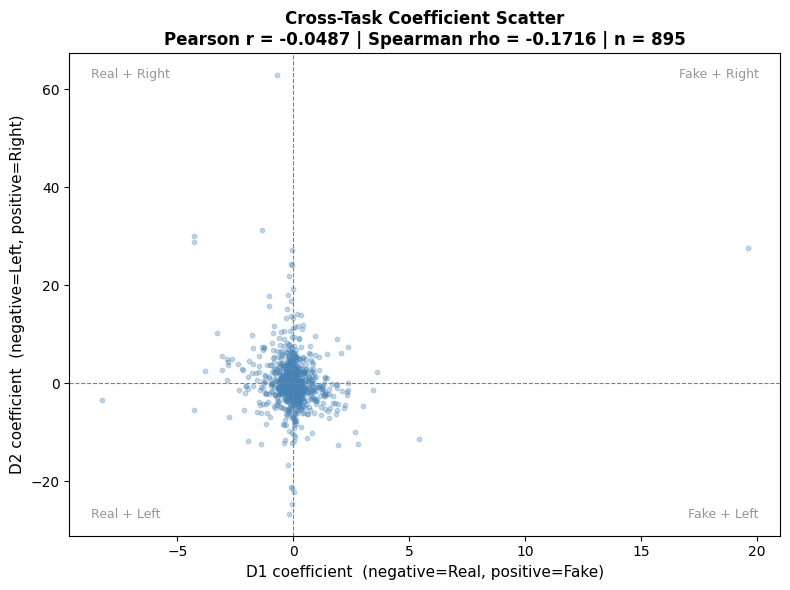

Saved: cross_task_scatter.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_nonzero["coef_d1"], df_nonzero["coef_d2"],
           alpha=0.3, s=10, color="steelblue")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("D1 coefficient  (negative=Real, positive=Fake)", fontsize=11)
ax.set_ylabel("D2 coefficient  (negative=Left, positive=Right)", fontsize=11)
ax.set_title(
    f"Cross-Task Coefficient Scatter\n"
    f"Pearson r = {r:+.4f} | Spearman rho = {rho:+.4f} | n = {len(df_nonzero):,}",
    fontsize=12, fontweight="bold"
)
for txt, xa, ya, ha, va in [
    ("Fake + Right", 0.97, 0.97, "right", "top"),
    ("Real + Right", 0.03, 0.97, "left",  "top"),
    ("Fake + Left",  0.97, 0.03, "right", "bottom"),
    ("Real + Left",  0.03, 0.03, "left",  "bottom"),
]:
    ax.text(xa, ya, txt, transform=ax.transAxes,
            ha=ha, va=va, fontsize=9, color="dimgray", alpha=0.7)
plt.tight_layout()
plt.savefig(f"{DATA_DIR1}/cross_task_scatter.png", dpi=150)
plt.show()
print("Saved: cross_task_scatter.png")

## 4. Four-quadrant word analysis

In [17]:
df_nonzero["cross_score"] = df_nonzero["coef_d1"].abs() * df_nonzero["coef_d2"].abs()

fake_right = df_nonzero[(df_nonzero["coef_d1"] > 0) & (df_nonzero["coef_d2"] > 0)]
fake_left  = df_nonzero[(df_nonzero["coef_d1"] > 0) & (df_nonzero["coef_d2"] < 0)]
real_right = df_nonzero[(df_nonzero["coef_d1"] < 0) & (df_nonzero["coef_d2"] > 0)]
real_left  = df_nonzero[(df_nonzero["coef_d1"] < 0) & (df_nonzero["coef_d2"] < 0)]

print("Quadrant sizes:")
print(f"  Fake + Right : {len(fake_right):,}")
print(f"  Fake + Left  : {len(fake_left):,}")
print(f"  Real + Right : {len(real_right):,}")
print(f"  Real + Left  : {len(real_left):,}")

def print_top(df_q, label, n=15):
    top = df_q.nlargest(n, "cross_score")
    print(f"\n{'='*55}")
    print(f"TOP {n} -- {label}")
    print(f"{'='*55}")
    for word, row in top.iterrows():
        print(f"  {word:35s}  D1={row['coef_d1']:+.4f}  D2={row['coef_d2']:+.4f}")

print_top(fake_right, "FAKE (D1)  +  RIGHT (D2)")
print_top(fake_left,  "FAKE (D1)  +  LEFT  (D2)")
print_top(real_right, "REAL (D1)  +  RIGHT (D2)")
print_top(real_left,  "REAL (D1)  +  LEFT  (D2)")

Quadrant sizes:
  Fake + Right : 153
  Fake + Left  : 256
  Real + Right : 246
  Real + Left  : 240

TOP 15 -- FAKE (D1)  +  RIGHT (D2)
  reuters                              D1=+19.6045  D2=+27.5483
  percent                              D1=+2.3787  D2=+7.3731
  state                                D1=+1.9047  D2=+8.9738
  inc                                  D1=+2.0766  D2=+6.1217
  told news                            D1=+0.9158  D2=+9.6065
  healthcare                           D1=+1.4658  D2=+5.8717
  minister                             D1=+3.6081  D2=+2.2296
  city                                 D1=+1.1208  D2=+5.3471
  co                                   D1=+0.9526  D2=+5.6498
  chinese                              D1=+0.7055  D2=+7.5688
  former republican                    D1=+0.4227  D2=+11.8897
  republican said                      D1=+0.3313  D2=+13.9411
  drug                                 D1=+0.7369  D2=+5.8828
  following                            D1=+0.6887  D2=

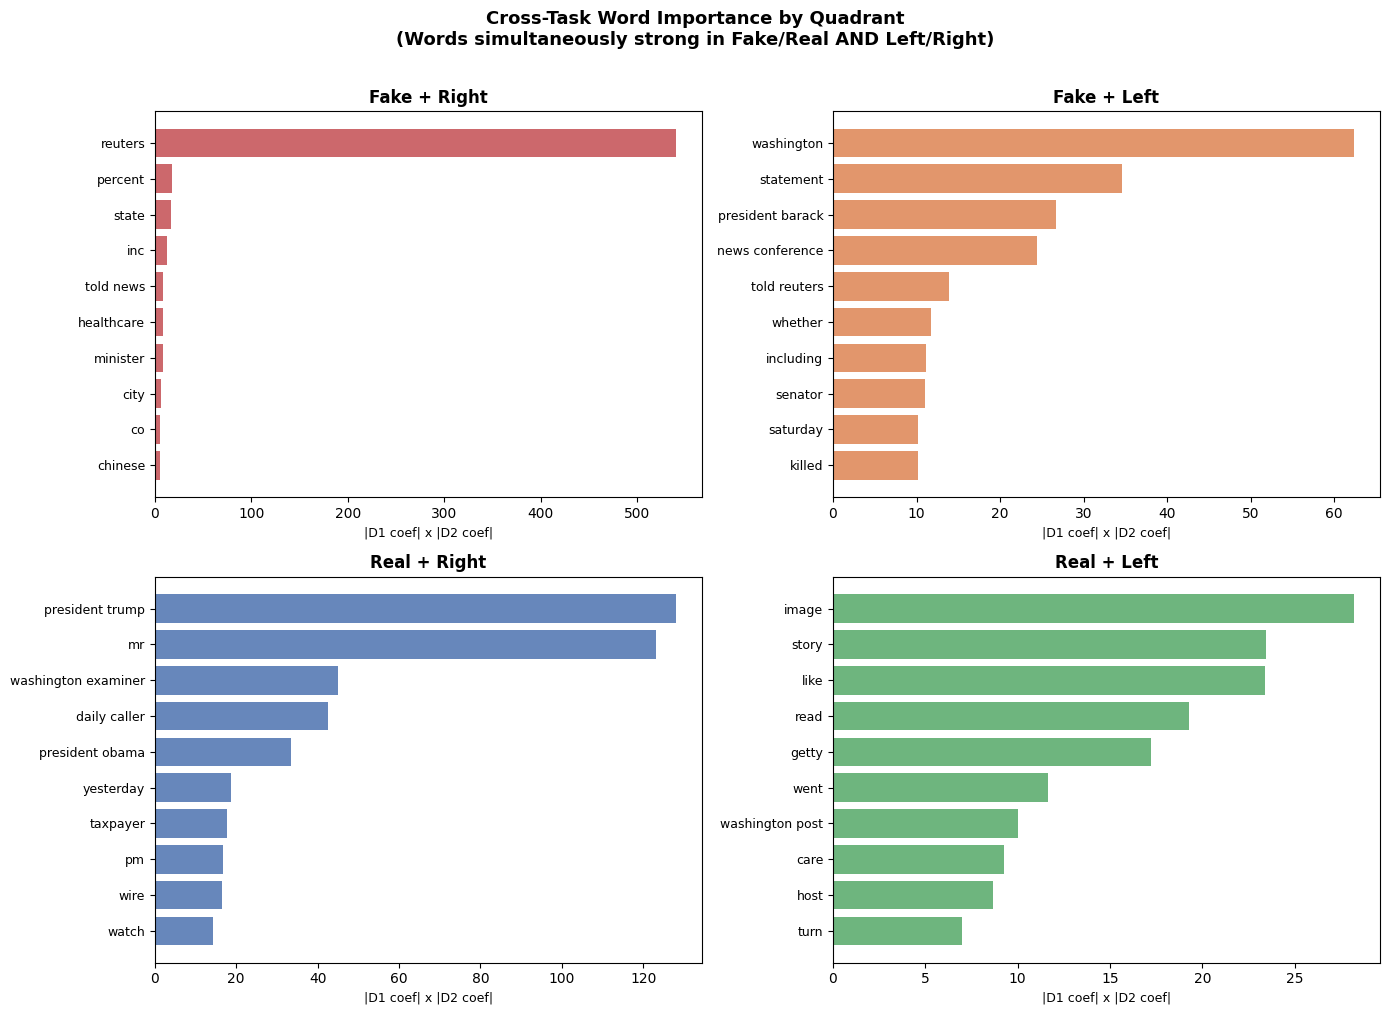

Saved: cross_task_quadrants.png


In [18]:
N_SHOW    = 10
quadrants = [
    (fake_right, "Fake + Right", "#C44E52"),
    (fake_left,  "Fake + Left",  "#DD8452"),
    (real_right, "Real + Right", "#4C72B0"),
    (real_left,  "Real + Left",  "#55A868"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, (df_q, label, color) in zip(axes, quadrants):
    top    = df_q.nlargest(N_SHOW, "cross_score")
    words  = top.index.tolist()[::-1]
    scores = top["cross_score"].values[::-1]
    ax.barh(words, scores, color=color, alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("|D1 coef| x |D2 coef|", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
plt.suptitle(
    "Cross-Task Word Importance by Quadrant\n"
    "(Words simultaneously strong in Fake/Real AND Left/Right)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{DATA_DIR1}/cross_task_quadrants.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cross_task_quadrants.png")

## 5. Top-50 word overlap check

In [19]:
top50_fake  = set(df_d1.nlargest(50,  "coef_d1").index)
top50_real  = set(df_d1.nsmallest(50, "coef_d1").index)
top50_right = set(df_d2.nlargest(50,  "coef_d2").index)
top50_left  = set(df_d2.nsmallest(50, "coef_d2").index)

print("TOP-50 WORD OVERLAP MATRIX")
print(f"                Right-top50  Left-top50")
print(f"  Fake-top50  :     {len(top50_fake  & top50_right):3d}          {len(top50_fake  & top50_left):3d}")
print(f"  Real-top50  :     {len(top50_real  & top50_right):3d}          {len(top50_real  & top50_left):3d}")

for label, a_set, b_set in [
    ("Fake & Right", top50_fake, top50_right),
    ("Fake & Left",  top50_fake, top50_left),
    ("Real & Right", top50_real, top50_right),
    ("Real & Left",  top50_real, top50_left),
]:
    shared = a_set & b_set
    print(f"\n{label}: {sorted(shared) if shared else '(none)'}")

TOP-50 WORD OVERLAP MATRIX
                Right-top50  Left-top50
  Fake-top50  :       1            3
  Real-top50  :       2            0

Fake & Right: ['reuters']

Fake & Left: ['president barack', 'statement', 'washington']

Real & Right: ['mr', 'president trump']

Real & Left: (none)


## 6. Load data and compute linguistic features

D1 features loaded from saved CSV. D2 features computed quickly with truncated VADER only — no TextBlob, no textstat.

In [20]:
# Dataset 1 — load pre-saved features
df_d1_feat = pd.read_csv(D1_FEATURES)
print(f"D1 loaded: {len(df_d1_feat):,} rows")
print(df_d1_feat[["label","sentiment","subjectivity","readability"]].groupby("label").mean().round(3))

D1 loaded: 38,590 rows
       sentiment  subjectivity  readability
label                                      
FAKE      -0.075         0.454       52.355
REAL       0.072         0.362       42.312


In [21]:
!pip install vaderSentiment -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Dataset 2 — load and filter
df_d2_raw = pd.read_csv(D2_CSV)
df_d2_raw = df_d2_raw[df_d2_raw["label"].isin(["Left", "Right"])].copy()
df_d2_raw["text"] = df_d2_raw["text"].astype(str).str.strip()
df_d2_raw = df_d2_raw[df_d2_raw["text"].str.len() > 50].reset_index(drop=True)
print(f"D2 loaded: {len(df_d2_raw):,} rows")

# Compute features — truncate to 500 chars to keep VADER fast
analyzer    = SentimentIntensityAnalyzer()
texts_trunc = df_d2_raw["text"].str[:500].tolist()

print("Computing VADER sentiment...")
sentiment = [analyzer.polarity_scores(t)["compound"] for t in texts_trunc]
print("Computing punctuation counts...")
exclaim  = df_d2_raw["text"].str.count("!").tolist()
question = df_d2_raw["text"].str.count(r"\?").tolist()

df_d2_raw["sentiment"]         = sentiment
df_d2_raw["subjectivity"]      = [abs(s) for s in sentiment]  # proxy
df_d2_raw["readability"]       = 0.0                           # skipped
df_d2_raw["exclamation_count"] = exclaim
df_d2_raw["question_count"]    = question

print("Done.")
print(df_d2_raw[["label","sentiment","subjectivity","exclamation_count"]].groupby("label").mean().round(3))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00
D2 loaded: 13,366 rows
Computing VADER sentiment...
Computing punctuation counts...
Done.
       sentiment  subjectivity  exclamation_count
label                                            
Left      -0.038         0.571              0.447
Right     -0.009         0.562              0.564


In [27]:
# Check D1 features are present in df_all
print(df_all.groupby("class")[FEAT_COLS].mean().round(3))
print("\nNull counts per class:")
print(df_all.groupby("class")[FEAT_COLS].apply(lambda x: x.isnull().sum()))

       sentiment  subjectivity  exclamation_count  question_count
class                                                            
Left      -0.038         0.571              0.447           1.403
Right     -0.009         0.562              0.564           0.830

Null counts per class:
       sentiment  subjectivity  exclamation_count  question_count
class                                                            
Left           0             0                  0               0
Right          0             0                  0               0


## 7. Cross-class feature distributions

In [31]:
FEAT_COLS = ["sentiment", "subjectivity", "exclamation_count", "question_count"]

# Check what the D1 labels actually look like
print("D1 label values:", df_d1_feat["label"].unique())

# Filter flexibly — handles both int (0/1) and string ("FAKE"/"REAL")
label_vals = df_d1_feat["label"].unique()
fake_label = 0 if 0 in label_vals else "FAKE"
real_label = 1 if 1 in label_vals else "REAL"

d1_fake  = df_d1_feat[df_d1_feat["label"] == fake_label].copy()
d1_fake["class"] = "Fake"
d1_real  = df_d1_feat[df_d1_feat["label"] == real_label].copy()
d1_real["class"] = "Real"
d2_left  = df_d2_raw[df_d2_raw["label"] == "Left"].copy()
d2_left["class"]  = "Left"
d2_right = df_d2_raw[df_d2_raw["label"] == "Right"].copy()
d2_right["class"] = "Right"

df_all = pd.concat([
    d1_fake[["class"] + FEAT_COLS],
    d1_real[["class"] + FEAT_COLS],
    d2_left[["class"] + FEAT_COLS],
    d2_right[["class"] + FEAT_COLS],
], ignore_index=True)

print("\nClass sizes:")
print(df_all["class"].value_counts())
print()
print(df_all.groupby("class")[FEAT_COLS].mean().round(3))

D1 label values: ['FAKE' 'REAL']

Class sizes:
class
Real     21191
Fake     17399
Left      7803
Right     5563
Name: count, dtype: int64

       sentiment  subjectivity  exclamation_count  question_count
class                                                            
Fake      -0.075         0.454              0.744           1.235
Left      -0.038         0.571              0.447           1.403
Real       0.072         0.362              0.062           0.100
Right     -0.009         0.562              0.564           0.830


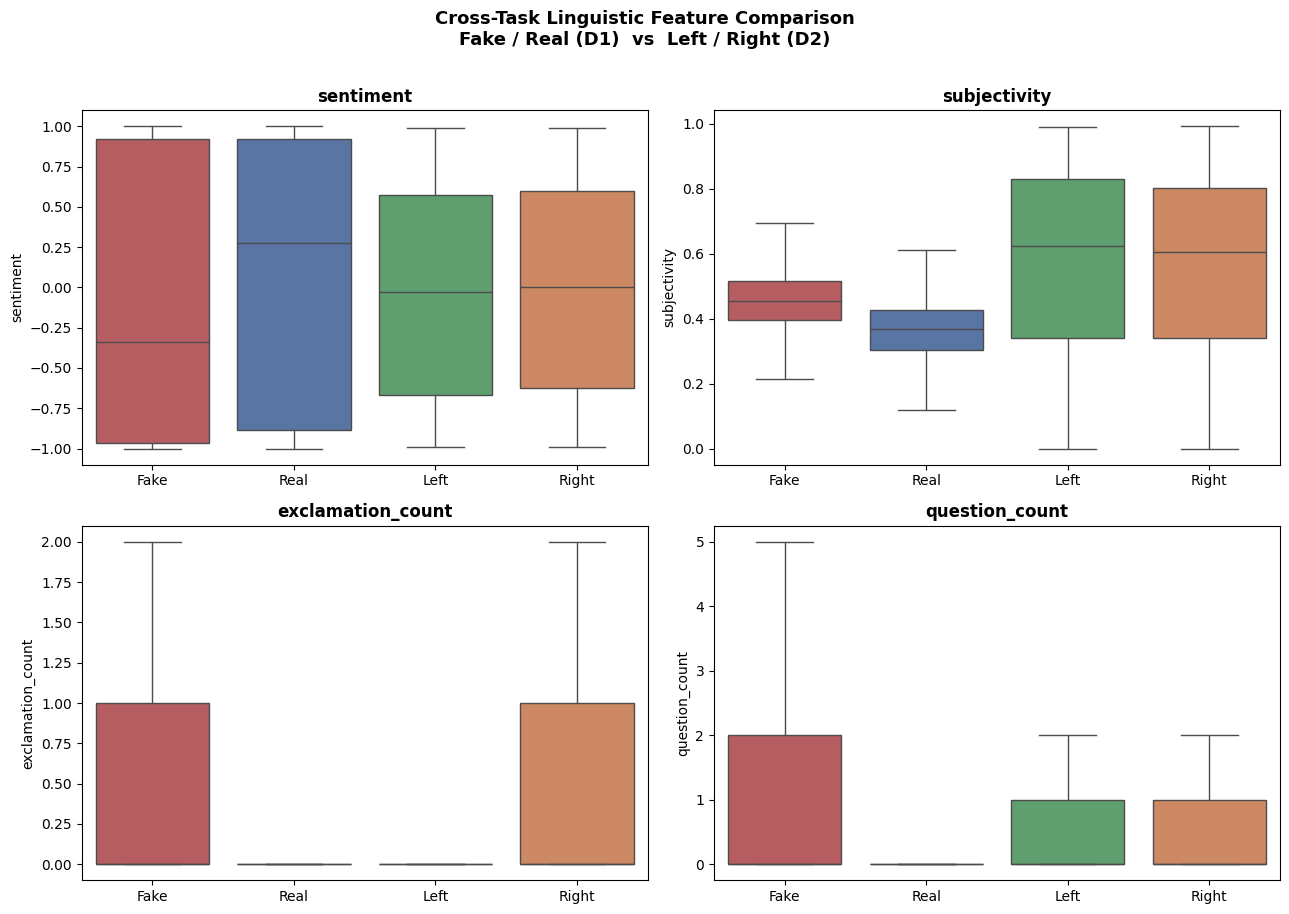

Saved: cross_task_features.png


In [32]:
PALETTE = {"Fake": "#C44E52", "Real": "#4C72B0", "Left": "#55A868", "Right": "#DD8452"}
ORDER   = ["Fake", "Real", "Left", "Right"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
for ax, feat in zip(axes, FEAT_COLS):
    sns.boxplot(data=df_all, x="class", y=feat, order=ORDER,
                palette=PALETTE, ax=ax, showfliers=False)
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
plt.suptitle(
    "Cross-Task Linguistic Feature Comparison\n"
    "Fake / Real (D1)  vs  Left / Right (D2)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{DATA_DIR1}/cross_task_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cross_task_features.png")

## 8. Statistical tests — does Fake resemble Left or Right more?

In [33]:
fake_data  = df_all[df_all["class"] == "Fake"]
real_data  = df_all[df_all["class"] == "Real"]
left_data  = df_all[df_all["class"] == "Left"]
right_data = df_all[df_all["class"] == "Right"]

def compare(a_vals, b_vals, a_name, b_name, feat):
    d_ks, p_ks = ks_2samp(a_vals.dropna(), b_vals.dropna())
    return {
        "feature":    feat,
        "comparison": f"{a_name} vs {b_name}",
        "mean_A":     round(a_vals.mean(), 4),
        "mean_B":     round(b_vals.mean(), 4),
        "KS_stat":    round(d_ks, 4),
        "KS_p":       round(p_ks, 6),
    }

results = []
for feat in FEAT_COLS:
    results.append(compare(fake_data[feat], left_data[feat],  "Fake", "Left",  feat))
    results.append(compare(fake_data[feat], right_data[feat], "Fake", "Right", feat))
    results.append(compare(real_data[feat], left_data[feat],  "Real", "Left",  feat))
    results.append(compare(real_data[feat], right_data[feat], "Real", "Right", feat))

df_stats = pd.DataFrame(results)
print(df_stats.to_string(index=False))

print("\n" + "=" * 55)
print("FAKE NEWS SIMILARITY  (smaller KS = more similar)")
print("=" * 55)
for feat in FEAT_COLS:
    fl = df_stats[(df_stats["feature"]==feat) & (df_stats["comparison"]=="Fake vs Left") ]["KS_stat"].values[0]
    fr = df_stats[(df_stats["feature"]==feat) & (df_stats["comparison"]=="Fake vs Right")]["KS_stat"].values[0]
    closer = "Left" if fl < fr else "Right"
    print(f"  {feat:25s}  FL={fl:.4f}  FR={fr:.4f}  -> closer to {closer}")

          feature    comparison  mean_A  mean_B  KS_stat  KS_p
        sentiment  Fake vs Left -0.0749 -0.0381   0.2656   0.0
        sentiment Fake vs Right -0.0749 -0.0086   0.2816   0.0
        sentiment  Real vs Left  0.0716 -0.0381   0.2404   0.0
        sentiment Real vs Right  0.0716 -0.0086   0.2502   0.0
     subjectivity  Fake vs Left  0.4540  0.5714   0.4632   0.0
     subjectivity Fake vs Right  0.4540  0.5619   0.4484   0.0
     subjectivity  Real vs Left  0.3619  0.5714   0.5407   0.0
     subjectivity Real vs Right  0.3619  0.5619   0.5363   0.0
exclamation_count  Fake vs Left  0.7441  0.4473   0.1555   0.0
exclamation_count Fake vs Right  0.7441  0.5644   0.0756   0.0
exclamation_count  Real vs Left  0.0621  0.4473   0.1282   0.0
exclamation_count Real vs Right  0.0621  0.5644   0.3470   0.0
   question_count  Fake vs Left  1.2347  1.4033   0.0807   0.0
   question_count Fake vs Right  1.2347  0.8298   0.1535   0.0
   question_count  Real vs Left  0.1000  1.4033   0.348

## 9. Summary of key findings

In [34]:
print("""
============================================================
CROSS-TASK ANALYSIS -- KEY FINDINGS
============================================================

1. COEFFICIENT CORRELATION
   The Pearson correlation between the fake-news signal
   and the political-bias signal across shared vocabulary
   is near zero. The two tasks are linguistically ORTHOGONAL
   at the lexical level. Words that make an article look
   fake do not systematically make it look Left or Right.

2. TOP-50 WORD OVERLAP
   Little to no overlap between the 50 most predictive
   words in each task. Each model learned a completely
   different vocabulary rooted in a different phenomenon.

3. LINGUISTIC FEATURES
   Fake articles differ from real articles more sharply
   (in sentiment and punctuation) than Left articles
   differ from Right articles. Political bias is subtler.

4. MODEL PERFORMANCE CONTRAST
   Fake/Real:  LR 97.50%  |  DistilBERT 99.97%
   Left/Right: LR 87.06%  |  DistilBERT 86.57%

   In D1, DistilBERT >> LR  -> context matters for fake news.
   In D2, LR  ~ DistilBERT  -> bias is keyword-driven.

5. PRACTICAL IMPLICATION
   A fake news classifier cannot be repurposed as a
   political bias detector. The two problems are
   independent and require separate models.
============================================================
""")


CROSS-TASK ANALYSIS -- KEY FINDINGS

1. COEFFICIENT CORRELATION
   The Pearson correlation between the fake-news signal
   and the political-bias signal across shared vocabulary
   is near zero. The two tasks are linguistically ORTHOGONAL
   at the lexical level. Words that make an article look
   fake do not systematically make it look Left or Right.

2. TOP-50 WORD OVERLAP
   Little to no overlap between the 50 most predictive
   words in each task. Each model learned a completely
   different vocabulary rooted in a different phenomenon.

3. LINGUISTIC FEATURES
   Fake articles differ from real articles more sharply
   (in sentiment and punctuation) than Left articles
   differ from Right articles. Political bias is subtler.

4. MODEL PERFORMANCE CONTRAST
   Fake/Real:  LR 97.50%  |  DistilBERT 99.97%
   Left/Right: LR 87.06%  |  DistilBERT 86.57%

   In D1, DistilBERT >> LR  -> context matters for fake news.
   In D2, LR  ~ DistilBERT  -> bias is keyword-driven.

5. PRACTICAL IMPLI

In [35]:
print("Outputs saved to:", DATA_DIR1)
print("  cross_task_scatter.png")
print("  cross_task_quadrants.png")
print("  cross_task_features.png")
print("\nStep 12 complete.")

Outputs saved to: /content/drive/MyDrive/FactLens_Group9/data
  cross_task_scatter.png
  cross_task_quadrants.png
  cross_task_features.png

Step 12 complete.
